In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

from torch.utils.tensorboard import SummaryWriter

from tqdm import tqdm



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
exp_name = 'rossler_14k_loss_rk5'

dt          = 0.01
Nbatch      = 10000
tepoch      = 100 
tvalid      = 3   
num_epochs  = 14000
hidden_size = 100 

In [4]:
mu_u = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32, device=device)
su   = torch.tensor([10.0, 10.0, 10.0], dtype=torch.float32, device=device)
mu_p = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32, device=device)
sp   = torch.tensor([10.0, 10.0, 10.0], dtype=torch.float32, device=device)
mu_g = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32, device=device)
sg   = torch.tensor([14.0, 101.0, 142.0], dtype=torch.float32, device=device)

In [5]:
def f(u, p):
    x, y, z = u[...,0], u[...,1], u[...,2]
    a, b, c = p[...,0], p[...,1], p[...,2]
    dx = -y - z
    dy =  x + a*y
    dz =  b + z*(x - c)
    
    return torch.stack([dx, dy, dz], dim=-1)


def rossler_rhs(_, y, a, b, c):
    x, y1, z = y
    dx = -y1 - z
    dy =  x + a * y1
    dz =  b + z * (x - c)
    return [dx, dy, dz]

In [6]:
class RosslerNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(6, hidden_size)
        self.act = nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_size, 3)

    def forward(self, u, p):

        u0 = (u - mu_u) / su
        p0 = (p - mu_p) / sp

        h  = self.act(self.fc1(torch.cat([u0, p0], dim=-1)))
        g  = self.fc2(h)

        d = dt * (g * sg + mu_g)
        return d

model = RosslerNet().to(device)

In [7]:
def compute_error_heun(u, p, d):

    k1 = f(u, p)
    k2 = f(u + d, p)
    
    e  = d - 0.5 * dt * (k1 + k2)
    
    return e

def compute_error_rk2(u, p, d):

    k1 = f(u, p)
    k2 = f(u + dt * k1, p)
    
    e  = d - 0.5 * dt * (k1 + k2)
    
    return e

def compute_error_rk4(u, p, d):

    k1 = f(u, p)
    k2 = f(u + 0.5 * dt * k1, p)
    k3 = f(u + 0.5 * dt * k2, p)
    k4 = f(u + dt * k3, p)

    e = d - dt * (k1 + 2*k2 + 2*k3 + k4) / 6.0

    return e

def compute_error_rk5(u, p, d):

    # классический «Cash–Karp»
    b21 =   1/5

    b31 =   3/40
    b32 =   9/40

    b41 =   3/10
    b42 =  -9/10
    b43 =   6/5

    b51 =  -11/54
    b52 =   5/2
    b53 =  -70/27
    b54 =   35/27

    b61 =  1631/55296
    b62 =    175/512
    b63 =    575/13824
    b64 =  44275/110592
    b65 =    253/4096

    c1 =   37/378
    c2 =        0
    c3 =   250/621
    c4 =   125/594
    c5 =        0
    c6 =   512/1771


    k1 = f(u,             p)
    k2 = f(u + dt*b21*k1, p)
    k3 = f(u + dt*(b31*k1 + b32*k2), p)
    k4 = f(u + dt*(b41*k1 + b42*k2 + b43*k3), p)
    k5 = f(u + dt*(b51*k1 + b52*k2 + b53*k3 + b54*k4), p)
    k6 = f(u + dt*(b61*k1 + b62*k2 + b63*k3 + b64*k4 + b65*k5), p)

    incr = dt * (c1*k1 + c2*k2 + c3*k3 + c4*k4 + c5*k5 + c6*k6)

    e = d - incr

    return e


def compute_error_rk6(u, p, d):

    #экстраполяцию Ричардсона
    
    k1 = f(u, p)
    k2 = f(u + 0.5 * dt * k1, p)
    k3 = f(u + 0.5 * dt * k2, p)
    k4 = f(u +     dt * k3, p)
    y_full = u + (dt * (k1 + 2*k2 + 2*k3 + k4) / 6.0)

    k1 = f(u, p)
    k2 = f(u + 0.25 * dt * k1, p)
    k3 = f(u + 0.25 * dt * k2, p)
    k4 = f(u + 0.5  * dt * k3, p)
    y_mid = u + (dt/2) * (k1 + 2*k2 + 2*k3 + k4) / 6.0

    # второй полушаг от y_mid
    k1 = f(y_mid, p)
    k2 = f(y_mid + 0.25 * dt * k1, p)
    k3 = f(y_mid + 0.25 * dt * k2, p)
    k4 = f(y_mid + 0.5  * dt * k3, p)
    y_half = y_mid + (dt/2) * (k1 + 2*k2 + 2*k3 + k4) / 6.0

    y_extr = (32.0 * y_half - y_full) / 31.0

    e = d - y_extr
    return e



def MRNE(e, u):
    num = torch.sum(torch.abs(e), dim=-1)
    den = torch.sum(torch.abs(u), dim=-1)
    return torch.mean(num / den)

In [33]:
def get_exp_data(ckpt, solver):
    
    a, b, c = 0.1, 0.1, 6.
    t0, t1, dt_vis = 0.0, 300.0, dt
    t_eval = np.arange(t0, t1+dt_vis, dt_vis)

    y0 = np.array([1.0, 1.0, 1.0], dtype=np.float32)
    
    
    sol = solve_ivp(
        rossler_rhs,
        (t0, t1),
        y0,
        args=(a, b, c),
        t_eval=t_eval,
        method=solver
    )


    model.load_state_dict(torch.load(f'ckpt/{ckpt}.pt', map_location=device))
    model.to(device).eval()
    
    us = torch.empty((len(t_eval), 3), device=device)
    u = torch.tensor(y0, device=device)
    p = torch.tensor([a, b, c], dtype=torch.float32, device=device)
    
    with torch.no_grad():
        for i in range(len(t_eval)):
            us[i] = u
            d = model(u.unsqueeze(0), p.unsqueeze(0)).squeeze(0)
            u = u + d

    u_model = us.cpu().numpy()

    return sol.y, u_model, t_eval

0.10379864606026347 1.359284072219209
0.029868387519131664 0.36873564636256667
0.4507719833132419 4.097561088909791


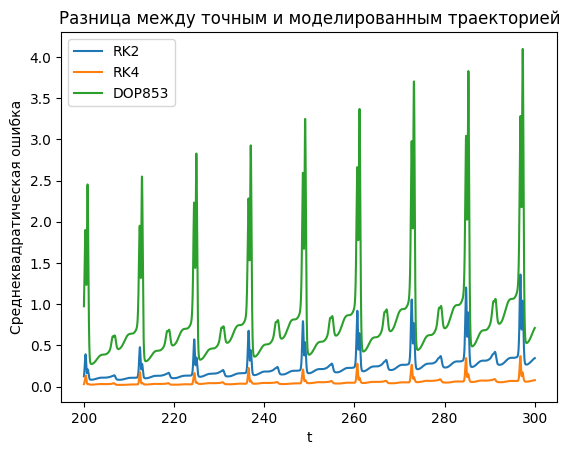

In [35]:
exp_names = [('rossler_14k_loss_rk2', 'RK23', 'RK2'), ('rossler_14k_loss_rk4', 'RK45', 'RK4'), ('rossler_14k_loss_rk5', 'RK45', 'DOP853')]

plt.figure()
transient_process = 20000

for ckpt, sovler, label in exp_names:
    y, u_model, t_eval = get_exp_data(ckpt, sovler)
    
    err = ((y.T - u_model) ** 2).mean(axis=1)
    print(np.mean(err), np.max(err))
    plt.plot(t_eval[transient_process:], err[transient_process:], label=label)


plt.xlabel('t')
plt.ylabel(f'Cреднеквадратическая ошибка')
plt.title('Разница между точным и моделированным траекторией')
plt.legend()
plt.show()

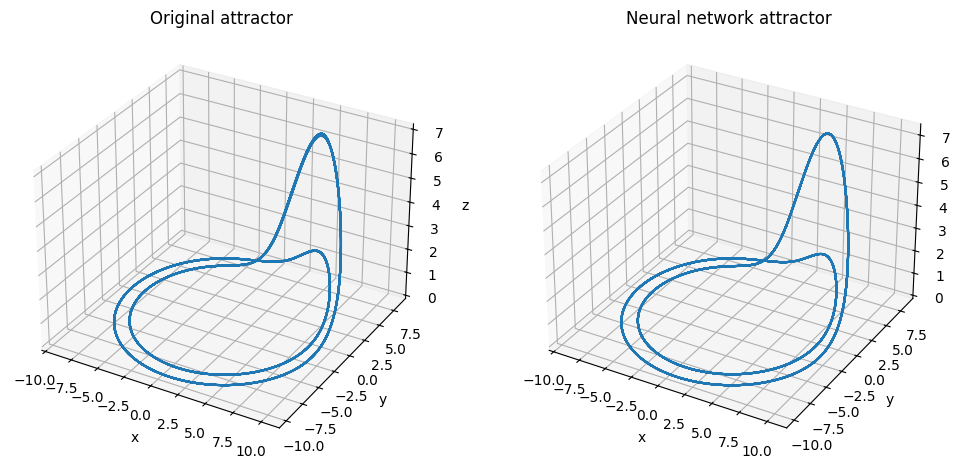

(np.float64(4.097561088909791), np.float64(0.4507719833132419))

In [16]:
exp_name = 'rossler_14k_loss_rk5'

a, b, c = 0.1, 0.1, 6.

method = 'RK45'

t0, t1, dt_vis = 0.0, 300.0, dt
t_eval = np.arange(t0, t1+dt_vis, dt_vis)


y0 = np.array([1.0, 1.0, 1.0], dtype=np.float32)

sol = solve_ivp(
    rossler_rhs,
    (t0, t1),
    y0,
    args=(a, b, c),
    t_eval=t_eval,
    method=method
)


model.load_state_dict(torch.load(f'ckpt/{exp_name}.pt', map_location=device))
model.to(device).eval()

us = torch.empty((len(t_eval), 3), device=device)
u = torch.tensor(y0, device=device)
p = torch.tensor([a, b, c], dtype=torch.float32, device=device)

with torch.no_grad():
    for i in range(len(t_eval)):
        us[i] = u
        d = model(u.unsqueeze(0), p.unsqueeze(0)).squeeze(0)
        u = u + d

u_model = us.cpu().numpy()


fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

ax1.plot(sol.y[0][transient_process:], sol.y[1][transient_process:], sol.y[2][transient_process:], label=method)
ax2.plot(u_model[:,0][transient_process:], u_model[:,1][transient_process:], u_model[:,2][transient_process:], label='Model')

ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.set_title("Original attractor")

ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
ax2.set_title("Neural network attractor")

plt.show()

np.max(err), np.mean(err)

In [18]:
def get_model_traj(exp_name, compute_func):
    
    mrnes = []
    
    model.load_state_dict(torch.load(f'ckpt/{exp_name}.pt', map_location=device))
    model.to(device).eval()

    us = torch.empty((len(t_eval), 3), device=device)
    u = torch.tensor(y0, device=device)
    p = torch.tensor([a, b, c], dtype=torch.float32, device=device)

    with torch.no_grad():
        for i in range(len(t_eval)):
            us[i] = u
            d = model(u.unsqueeze(0), p.unsqueeze(0)).squeeze(0)          
            
            e_traj = compute_func(u, p, d)
            mrnes.append(MRNE(e_traj, u).item())

            u = u + d

    u_model = us.cpu().numpy()
    
    return u_model, mrnes

358.68274247844096 4.962716913187874
423.8612763805881 10.298593564850377
423.8612763805881 10.298593564850377
0.00018287209968548268 1.9722547312472922e-05
0.00017317989841103554 2.1131996154270395e-05
0.00017318056779913604 2.1131891567165667e-05


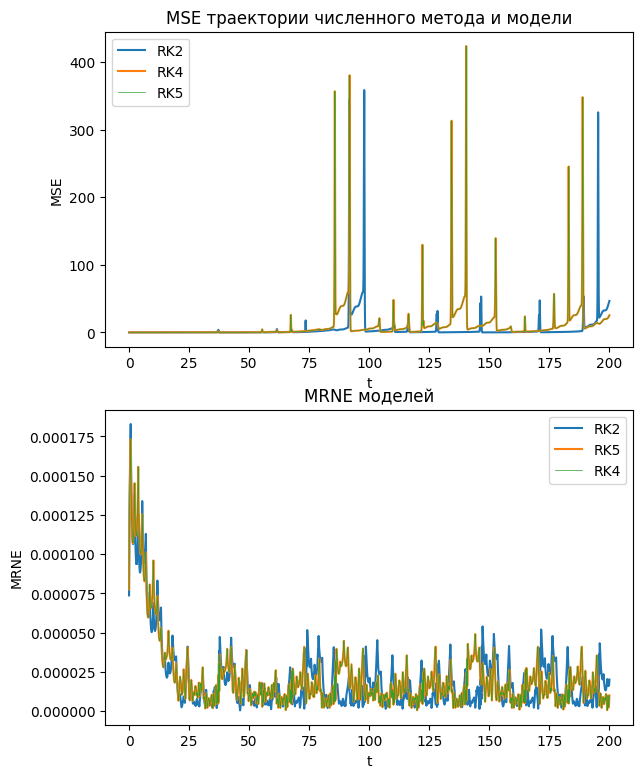

In [30]:
exp_name1 = 'rossler_14k_loss_rk2'
exp_name2 = 'rossler_14k_loss_rk4'
exp_name3 = 'rossler_14k_loss_rk5'

a, b, c = 0.15, 0.2, 10.
transient_process = 0

t0, t1, dt_vis = 0.0, 200.0, dt
t_eval = np.arange(t0, t1+dt_vis, dt_vis)


y0 = np.array([1.0, 1.0, 1.0], dtype=np.float32)

sol1 = solve_ivp(
    rossler_rhs,
    (t0, t1),
    y0,
    args=(a, b, c),
    t_eval=t_eval,
    method='RK23'
)

sol2 = solve_ivp(
    rossler_rhs,
    (t0, t1),
    y0,
    args=(a, b, c),
    t_eval=t_eval,
    method='RK45'
)



u_model1, mrne1 = get_model_traj(exp_name1, compute_error_rk2)
u_model2, mrne2 = get_model_traj(exp_name2, compute_error_rk4)
u_model3, mrne3 = get_model_traj(exp_name2, compute_error_rk5)

err1 = ((sol1.y.T - u_model1) ** 2).mean(axis=1)
err2 = ((sol2.y.T - u_model2) ** 2).mean(axis=1)
err3 = ((sol2.y.T - u_model3) ** 2).mean(axis=1)


fig = plt.figure(figsize=(15, 9))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(223)


ax1.plot(t_eval[transient_process:], err1[transient_process:], label='RK2')
ax1.plot(t_eval[transient_process:], err2[transient_process:], label='RK4')
ax1.plot(t_eval[transient_process:], err3[transient_process:], label='RK5', linewidth=0.5)

ax1.set_xlabel('t'); ax1.set_ylabel('MSE')
ax1.set_title("MSE траектории численного метода и модели")
ax1.legend()


ax2.plot(t_eval[transient_process:], mrne1[transient_process:], label='RK2')
ax2.plot(t_eval[transient_process:], mrne3[transient_process:], label='RK5')
ax2.plot(t_eval[transient_process:], mrne3[transient_process:], label='RK4', linewidth=0.5)

ax2.set_xlabel('t'); ax2.set_ylabel('MRNE')
ax2.set_title("MRNE моделей")
ax2.legend()


print(np.max(err1), np.mean(err1))
print(np.max(err2), np.mean(err2))
print(np.max(err3), np.mean(err3))

print(np.max(mrne1), np.mean(mrne1))
print(np.max(mrne2), np.mean(mrne2))
print(np.max(mrne3), np.mean(mrne3))

406.6763443031485 14.103405970663715
423.8612763805881 10.298593564850377
0.00014117789396550506 1.689407828645169e-05
0.00017317989841103554 2.1131996154270395e-05


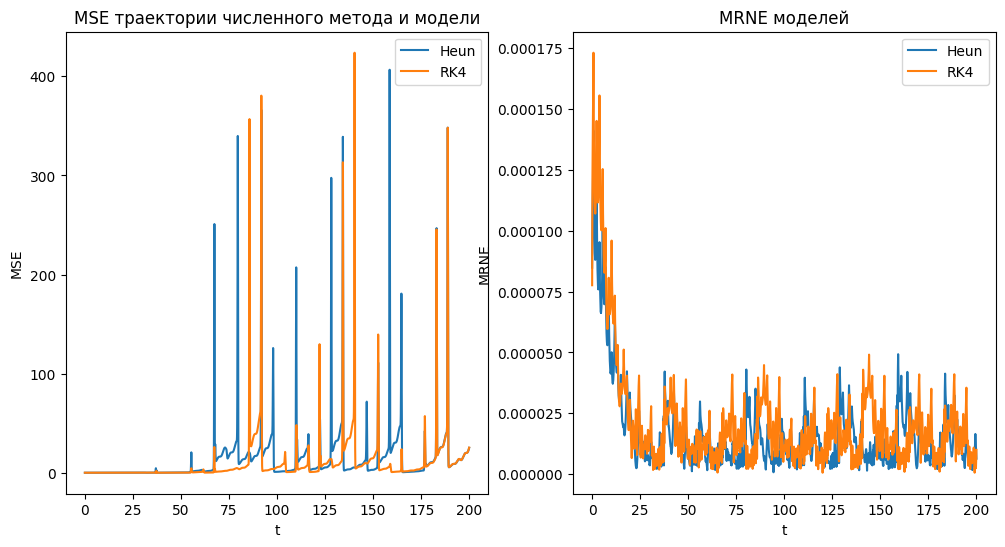

In [ ]:
exp_name1 = 'rossler_14k_loss_rk2'
exp_name2 = 'rossler_14k_loss_rk4'

a, b, c = 0.15, 0.2, 10.
transient_process = 0 #5000
method = 'RK45'

t0, t1, dt_vis = 0.0, 300.0, dt
t_eval = np.arange(t0, t1+dt_vis, dt_vis)


y0 = np.array([1.0, 1.0, 1.0], dtype=np.float32)

sol = solve_ivp(
    rossler_rhs,
    (t0, t1),
    y0,
    args=(a, b, c),
    t_eval=t_eval,
    method=method
)


u_model1, mrne1 = get_model_traj(exp_name1)
u_model2, mrne2 = get_model_traj(exp_name2)


err1 = ((sol.y.T - u_model1) ** 2).mean(axis=1)
err2 = ((sol.y.T - u_model2) ** 2).mean(axis=1)

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(t_eval, err1, label='Heun')
ax1.plot(t_eval, err2, label='RK4')

ax1.set_xlabel('t'); ax1.set_ylabel('MSE')
ax1.set_title("MSE траектории численного метода и модели")
ax1.legend()

ax2.plot(t_eval, mrne1, label='Heun')
ax2.plot(t_eval, mrne2, label='RK4')

ax2.set_xlabel('t'); ax2.set_ylabel('MRNE')
ax2.set_title("MRNE моделей")
ax2.legend()


print(np.max(err1), np.mean(err1))
print(np.max(err2), np.mean(err2))

print(np.max(mrne1), np.mean(mrne1))
print(np.max(mrne2), np.mean(mrne2))